# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

EXPLICAÇÃO DO QUE FOI ANÁLISADO...

In [1]:
# Bibliotecas utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Carregamento da base de dados
df = pd.read_csv('vendas_aguas_LGPD_tratada.csv', delimiter=';')

df.head()

,id_cliente,dt_entrega,dt_semana,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d
0,89,2023-01-02,Segunda,1,03/03,NaN,Verão,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1
1,102,2023-01-02,Segunda,1,0,NaN,Verão,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0
2,120,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0
3,50,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1
4,8,2023-01-02,Segunda,1,07/10,NaN,Verão,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1


**Atribuições das variáveis:** \
id_cliente = Identificador anonimizado do cliente; \
dt_entrega = Data de entrega da água; \
dt_semana = Dia da semana da entrega da água; \
qtd_aguas_entregues = Quantidade de vasilhames entregues no dia; \
qtd_aguas_ticket = Quantidade de tickets sendo utilizados; \
obs_pedido = Observações sobre a entrega; \
dt_estacao = Estação do ano da entrega; \
dt_ano = Apenas o ano da entrega; \
dt_mes = Apenas o mês da entrega; \
cli_dias_desde_ultimo_pedido = Quantidade de dias desde a última compra realizada pelo cliente; \
cli_intervalo_medio = Média de dias que o cliente leva entre um pedido e outro; \
cli_frequencia_pedidos = Quantidade total de pedidos acumulados do cliente até o momento; \
cli_media_aguas_por_pedido = Média de vasilhames comprados por pedido pelo cliente; \
cli_total_pedidos = Histórico total de pedidos feitos pelo cliente na base de dados; \
target_dt_proxima_compra = Data em que o cliente realizou o pedido seguinte (usada para calcular o alvo); \
target_dias_ate_recompra = Quantidade exata de dias entre o pedido atual e o próximo; \
target_vai_comprar_15d = Variável alvo binária (1 = comprou em até 15 dias, 0 = demorou mais de 15 dias ou não comprou).

In [3]:
# Paleta de cores padrão do projeto
PALETA = {
    "azul": "#4477AA",
    "vermelho": "#EE6677",
    "verde": "#228833",
    "roxo": "#AA3377",
    "amarelo": "#C8A600",
    "cinza": "#BEBEBE",
    "preto": "#000000"
}

## 1º - Perfil geral dos pedidos
Objetivo: compreender como os pedidos estão distribuídos ao longo do período analisado, identificando padrões de consumo, sazonalidade e comportamento da operação antes de analisar o perfil dos clientes.

### A) Distribuição da quantidade de águas entregues:

C:\Users\nneto\AppData\Local\Temp\ipykernel_10304\4013904047.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


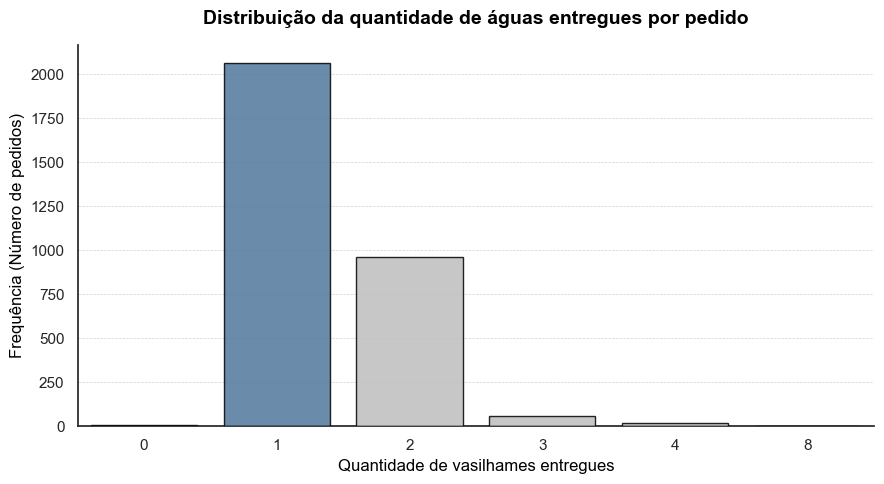

In [4]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(9, 5))

# Lógica para identificar qual quantidade tem o maior número de vendas (frequência)
frequencias = df['qtd_aguas_entregues'].value_counts()
maior_venda_qtd = frequencias.idxmax()

# Criação do mapeamento de cores dinâmico para cada barra
# O valor com maior frequência ganha "azul", se não, ganha "cinza"
cores_mapeadas = [
    PALETA["azul"] if valor == maior_venda_qtd else PALETA["cinza"] 
    for valor in sorted(df['qtd_aguas_entregues'].unique())
]

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.7)

# Plotagem do gráfico usando countplot
sns.countplot(
    data=df, 
    x='qtd_aguas_entregues', 
    palette=cores_mapeadas,
    edgecolor=PALETA["preto"],
    alpha=0.85,
    zorder=3
)

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Títulos e rótulos
plt.title('Distribuição da quantidade de águas entregues por pedido', fontsize=14, pad=15, fontweight='bold', color=PALETA["preto"])
plt.xlabel('Quantidade de vasilhames entregues', fontsize=12, color=PALETA["preto"])
plt.ylabel('Frequência (Número de pedidos)', fontsize=12, color=PALETA["preto"])

# Ajuste do layout
plt.tight_layout()
plt.show()

**Insights:** \
O gráfico mostra que a venda de vasilhames se concentra em entregas de baixo volume. Os pedidos de 1 vasilhame lideram com mais de 2.000 registros, seguidos por cerca de 1.000 pedidos de 2 unidades. Juntas, essas duas faixas representam a esmagadora maioria do histórico. Em contraste, os pedidos de 3 e 4 vasilhames têm presença residual (abaixo de 250 registros cada), enquanto as faixas de 0 e 8 unidades não possuem dados expressivos na escala.

### B) Evolução da demanda ao longo do tempo:

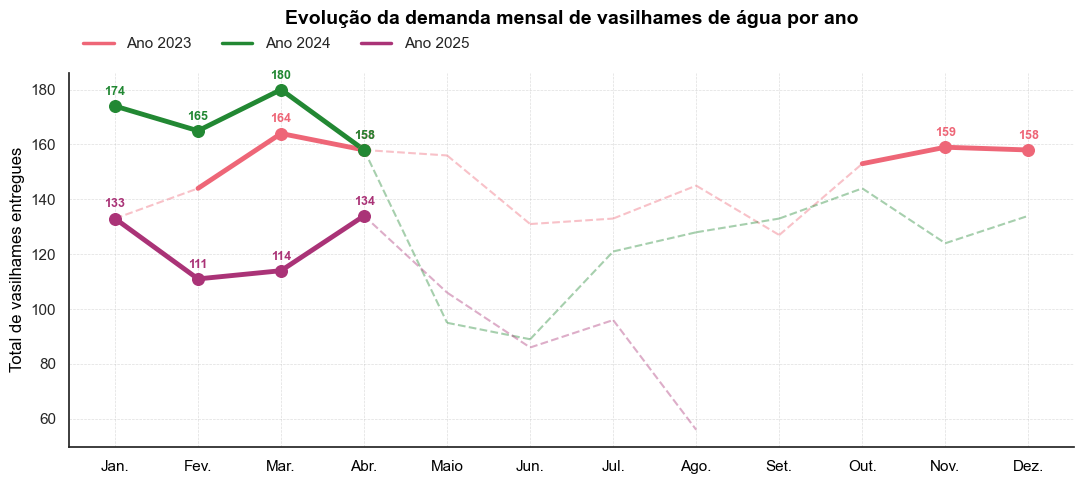

In [5]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(11, 5))

# Agrupamento dos dados por Ano e Mês, ordenando cronologicamente
demanda_temporal = df.groupby(['dt_ano', 'dt_mes'])['qtd_aguas_entregues'].sum().reset_index()
demanda_temporal = demanda_temporal.sort_values(['dt_ano', 'dt_mes']).reset_index(drop=True)

# Definição das cores vibrantes exclusivas para a identidade de cada ano
anos = sorted(demanda_temporal['dt_ano'].unique())
cores_vibrantes = [PALETA["vermelho"], PALETA["verde"], PALETA["roxo"], PALETA["amarelo"]]
cores_ano = {ano: cores_vibrantes[i % len(cores_vibrantes)] for i, ano in enumerate(anos)}

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.5)

# Plotagem baseada no comportamento individual de cada ano
for ano in anos:
    dados_ano = demanda_temporal[demanda_temporal['dt_ano'] == ano].sort_values('dt_mes').reset_index(drop=True)
    
    # TRATAMENTO DO BUG DE 2025: Se o ano for 2025 e houver meses zerados/incompletos no fim, remove
    if ano == 2025:
        dados_ano = dados_ano[dados_ano['qtd_aguas_entregues'] > 10].reset_index(drop=True)
        
    # Identifica os 4 maiores picos específicos DESTE ano
    top_4_do_ano = dados_ano.nlargest(4, 'qtd_aguas_entregues')['dt_mes'].tolist()
    cor_base = cores_ano[ano]
    
    # Desenha as linhas ligando os meses para este ano específico
    for i in range(len(dados_ano) - 1):
        mes_prox = dados_ano.loc[i+1, 'dt_mes']
        
        if mes_prox in top_4_do_ano:
            linewidth = 3.5          
            linestyle = '-'          
            alpha = 1.0              
        else:
            linewidth = 1.5          
            linestyle = '--'         
            alpha = 0.4              
            
        plt.plot(
            dados_ano.loc[i:i+1, 'dt_mes'], 
            dados_ano.loc[i:i+1, 'qtd_aguas_entregues'], 
            color=cor_base, 
            linewidth=linewidth, 
            linestyle=linestyle,
            alpha=alpha,
            zorder=3 if mes_prox in top_4_do_ano else 2
        )
        
    # Linha invisível para gerar a legenda com a cor contínua do ano
    plt.plot([], [], color=cor_base, linewidth=2.5, label=f'Ano {int(ano)}')

    # Adiciona pontos e numeração apenas nos 4 maiores picos deste ano específico
    for idx, row in dados_ano.iterrows():
        mes = row['dt_mes']
        valor = row['qtd_aguas_entregues']
        
        if mes in top_4_do_ano:
            plt.scatter(mes, valor, color=cor_base, s=70, zorder=4)
            
            plt.annotate(
                f'{int(valor)}', 
                (mes, valor), 
                textcoords="offset points", 
                xytext=(0, 8), 
                ha='center', 
                fontsize=9, 
                fontweight='bold', 
                color=cor_base,
                zorder=5
            )

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Títulos e rótulos personalizados
plt.title('Evolução da demanda mensal de vasilhames de água por ano', fontsize=14, pad=35, fontweight='bold', color=PALETA["preto"])
plt.ylabel('Total de vasilhames entregues', fontsize=12, color=PALETA["preto"])

# Lista com os nomes dos meses abreviados para o eixo X
meses_abreviados = ['Jan.', 'Fev.', 'Mar.', 'Abr.', 'Maio', 'Jun.', 'Jul.', 'Ago.', 'Set.', 'Out.', 'Nov.', 'Dez.']
plt.xticks(range(1, 13), meses_abreviados, color=PALETA["preto"])

plt.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(anos))

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico revela padrões consistentes e a evolução real do negócio:

- **Sazonalidade no 1º quadrimestre:** O pico de vendas no início dos anos se confirma como um padrão de mercado. Os maiores volumes ocorrem entre janeiro e abril, atingindo o topo em março, com 164 vasilhames em 2023 e 180 em 2024.
- **Crescimento ano a ano:** No primeiro quadrimestre, o ano de 2024 (linha verde) operou consistentemente acima de 2023 (linha vermelha), indicando expansão da carteira de clientes ou aumento no consumo.
- **Dados incompletos em 2025 (Linha roxa):** O ano iniciou em um patamar inferior aos anteriores. A queda a partir de maio e o encerramento em agosto não refletem uma crise, mas sim a ausência de registros.
- **Recuperação no final do ano:** O histórico de 2023 mostra que, após a retração do inverno (maio a setembro), ocorre uma reação forte na demanda a partir de outubro, mantendo patamares elevados de quase 160 vasilhames mensais até dezembro.

### C) Distribuição dos pedidos por dia da semana:

C:\Users\nneto\AppData\Local\Temp\ipykernel_10304\1867315927.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


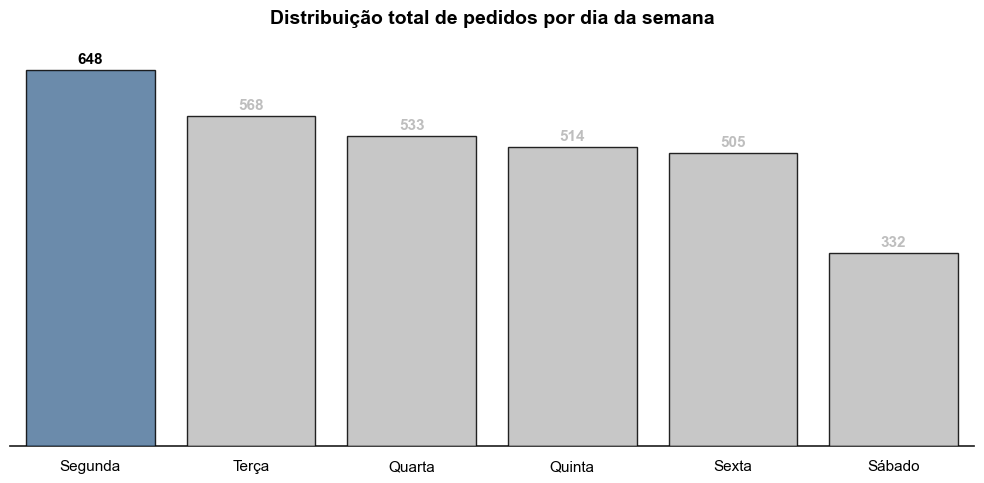

In [6]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# Contagem de pedidos por dia da semana e ordenação cronológica correta
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']
pedidos_por_dia = df['dt_semana'].value_counts().reindex(ordem_dias).fillna(0)

# Identifica o dia com o maior número de pedidos para o destaque visual
dia_pico = pedidos_por_dia.idxmax()

# Criação do mapeamento de cores: o dia de maior movimento ganha azul, os outros ganham cinza
cores_mapeadas = [
    PALETA["azul"] if dia == dia_pico else PALETA["cinza"] 
    for dia in ordem_dias
]

# Plotagem do gráfico de barras
sns.barplot(
    x=pedidos_por_dia.index, 
    y=pedidos_por_dia.values, 
    palette=cores_mapeadas,
    edgecolor=PALETA["preto"],
    alpha=0.85,
    zorder=3
)

# Adiciona as numerações de forma customizada em cima de cada barra
for i, valor in enumerate(pedidos_por_dia.values):
    if valor > 0:
        cor_texto = PALETA["preto"] if pedidos_por_dia.index[i] == dia_pico else PALETA["cinza"]
        
        plt.annotate(
            f'{int(valor)}', 
            (i, valor), 
            textcoords="offset points", 
            xytext=(0, 5), 
            ha='center', 
            fontsize=11, 
            fontweight='bold', 
            color=cor_texto,
            zorder=4
        )

# Remoção das bordas superior, direita e esquerda
sns.despine(top=True, right=True, left=True)

# Remoção completa dos números da escala do eixo Y
plt.yticks([])

# Título
plt.title('Distribuição total de pedidos por dia da semana', fontsize=14, pad=20, fontweight='bold', color=PALETA["preto"])
plt.xlabel('')

# Garantia de que os textos dos dias fiquem na cor padrão
plt.xticks(color=PALETA["preto"], fontsize=11)

plt.tight_layout()
plt.show()

**Insights:** \
A distribuição semanal indica uma concentração linear e decrescente do volume de entregas, com o início da semana concentrando o maior fluxo do negócio. A segunda-feira destaca-se isolada como o dia de maior movimento, registrando o pico máximo de 648 pedidos e sendo seguida de forma gradativa pela terça-feira com 568 pedidos. Entre a quarta-feira e a sexta-feira, observa-se uma estabilização da demanda em um patamar intermediário e uniforme, oscilando sutilmente entre 533 e 505 registros por dia. Por fim, o sábado apresenta uma redução drástica e acentuada nas atividades de entrega, fechando o período com o menor volume observado na série histórica, totalizando apenas 332 pedidos cadastrados.

## 2º - Perfil dos clientes
Objetivo: compreender o histórico de consumo dos clientes e identificar padrões comportamentais que possam explicar a frequência de compras e a recompra.

### A) Histórico de compras dos clientes:

C:\Users\nneto\AppData\Local\Temp\ipykernel_10304\1439752564.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


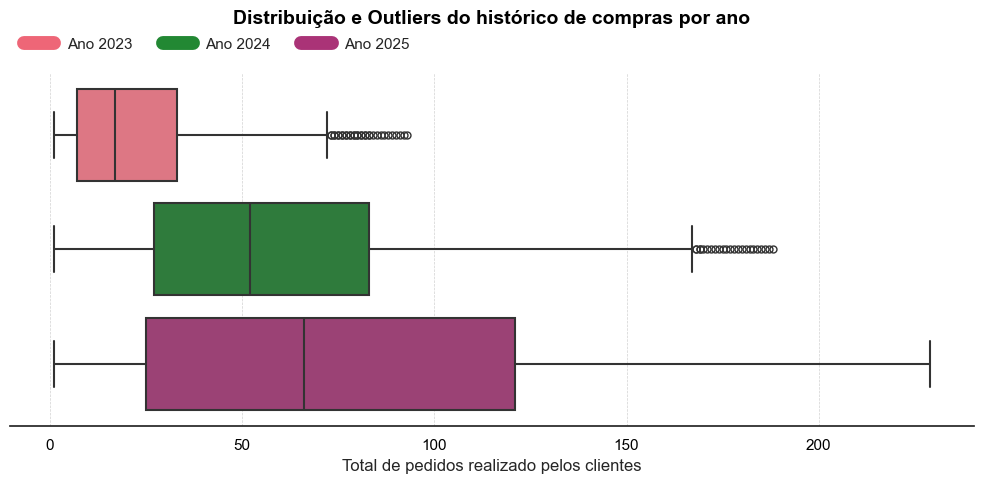

In [7]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# Preparação dos dados: Remove possíveis nulos e converte ano para string
dados_boxplot = df[['dt_ano', 'cli_total_pedidos']].dropna()
dados_boxplot['dt_ano'] = dados_boxplot['dt_ano'].astype(int).astype(str)

# Definição das cores oficiais de cada ano a partir da paleta definida
ordem_anos = sorted(dados_boxplot['dt_ano'].unique())
cores_vibrantes = [PALETA["vermelho"], PALETA["verde"], PALETA["roxo"], PALETA["amarelo"]]
cores_ano_dict = {ano: cores_vibrantes[i % len(cores_vibrantes)] for i, ano in enumerate(ordem_anos)}

# Criação da lista ordenada de cores para passar no parâmetro palette do boxplot
lista_cores = [cores_ano_dict[ano] for ano in ordem_anos]

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.7)

# Plotagem do Boxplot horizontal separado por ano
sns.boxplot(
    data=dados_boxplot,
    x='cli_total_pedidos',
    y='dt_ano',
    orient='h',
    palette=lista_cores,
    order=ordem_anos,
    linewidth=1.5,
    fliersize=5, # Tamanho dos pontos dos outliers
    zorder=3
)

# Remoção das bordas superior, direita e esquerda
sns.despine(top=True, right=True, left=True)

# Remoção dos rótulos e números
plt.ylabel('')
plt.yticks([])

# Título e rótulo do eixo X
plt.title('Distribuição e Outliers do histórico de compras por ano', fontsize=14, pad=35, fontweight='bold', color=PALETA["preto"])
plt.xlabel('Total de pedidos realizado pelos clientes')

# Força os ticks do eixo X a mostrarem a escala de pedidos de forma limpa
plt.xticks(color=PALETA["preto"], fontsize=11)

# Legenda
for ano in ordem_anos:
    plt.plot([], [], color=cores_ano_dict[ano], label=f'Ano {ano}', linewidth=10)
plt.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(ordem_anos))

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico de distribuição revela o comportamento de **fidelização e o ciclo de vida do cliente (LTV)** dentro da base histórica. O ano de 2023 destaca-se como o período inicial ou de captação, onde a esmagadora maioria dos compradores exibia um acumulado baixo, fixando-se abaixo de 35 pedidos totais e registrando pontos atípicos de no máximo 90 compras no histórico. Em 2024, observa-se o amadurecimento dessa base de clientes: os clientes continuaram recorrentes na distribuidora, fazendo com que a mediana do total de pedidos acumulados saltasse para a faixa dos 50 e o limite avançasse até a marca de 190 pedidos. Por fim, o ano de 2025 apresenta a maior dispersão e amplitude, provando que o tempo de casa gerou perfis distintos: enquanto novos clientes entram na base com volumes baixos, os clientes mais antigos acumularam mais de 120 compras, estendendo o teto histórico de fidelidade até a marca de 230 pedidos totais. Vale ressaltar que a base de 2025 está incompleta e cobre apenas até agosto; logo, o fato de o acumulado histórico já ter atingido patamares tão expressivos evidencia a força da recompra crônica e a retenção de longo prazo do negócio.

**Recomendações de negócio baseadas no LTV (Acumulado):** \
Com o entendimento de que os clientes ganham tração e acumulam pedidos conforme permanecem, as ações estratégicas devem focar em blindar essa jornada:

- **Régua de relacionamento por ciclo de vida (Gatilhos de recompra):**
    - **Hipótese:** Acredito que criar marcos comemorativos aumentará a retenção de clientes intermediários, porque os dados mostram que os clientes evoluem na plataforma e o grande desafio é fazê-los cruzar a barreira dos 35 pedidos rumo ao grupo de super-fiéis (120 a 230 pedidos).
    - **Ação:** Implementar automações de marketing que disparem benefícios progressivos (ex: cupons de desconto ou brindes) quando o cliente atingir os marcos de 10, 30 e 50 pedidos acumulados no sistema.
    - **Critério de sucesso:** Ao monitorar esse KPI saberei que funcionou quando o volume de clientes que estagnam na base inferior do gráfico (abaixo de 35 pedidos) diminuir em 20% no próximo ciclo.

### B) Intervalo médio entre compras:

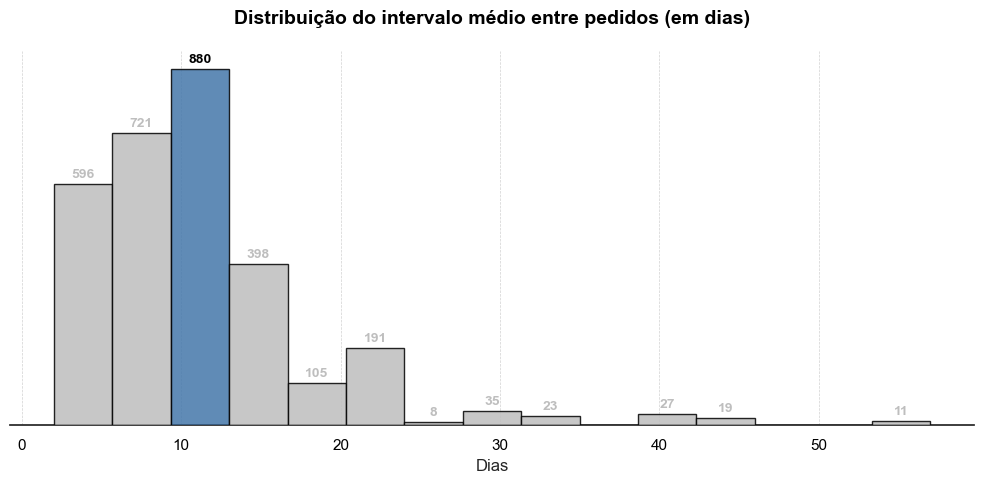

In [8]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 5))

# Filtro de nulos e limite da visualização até 60 dias para dar um zoom na distribuição real
dados_intervalo = df['cli_intervalo_medio'].dropna()
dados_intervalo = dados_intervalo[dados_intervalo <= 60]

# Criação do histograma com bins (caixas de agrupamento de dias)
contagens, limites_bins = np.histogram(dados_intervalo, bins=15)

# Descobre qual bin (faixa de dias) possui o maior número de registros para destacar
indice_maximo = contagens.argmax()

# Grades ao fundo
plt.grid(True, which='both', axis='both', color=PALETA["cinza"], linestyle='--', linewidth=0.5, alpha=0.7)

# Plotagem do Histograma utilizando patches para colorir as barras individualmente
n, bins, patches = plt.hist(
    dados_intervalo, 
    bins=limites_bins, 
    color=PALETA["cinza"], 
    edgecolor=PALETA["preto"], 
    alpha=0.85,
    zorder=3
)

# Aplica a cor azul especificamente na barra de maior frequência
patches[indice_maximo].set_facecolor(PALETA["azul"])

# Adiciona as numerações de forma customizada em cima de cada barra
for i in range(len(patches)):
    valor = int(contagens[i])
    if valor > 0:
        # Texto preto para a maior barra (azul) e cinza para as demais (cinza)
        cor_texto = PALETA["preto"] if i == indice_maximo else PALETA["cinza"]
        
        # Encontra o centro da barra no eixo X para posicionar o texto
        centro_x = (limites_bins[i] + limites_bins[i+1]) / 2
        
        plt.annotate(
            f'{valor}', 
             (centro_x, valor), 
            textcoords="offset points", 
            xytext=(0, 5), 
            ha='center', 
            fontsize=10, 
            fontweight='bold', 
            color=cor_texto,
            zorder=4
        )

# Remoção das bordas superior, direita e esquerda
sns.despine(top=True, right=True, left=True)

# Remove os números de escala
plt.yticks([])

# Título
plt.title('Distribuição do intervalo médio entre pedidos (em dias)', fontsize=14, pad=20, fontweight='bold', color=PALETA["preto"])
plt.xlabel('Dias')

# Garante que as marcações de dias no eixo X fiquem na cor padrão do seu projeto
plt.xticks(color=PALETA["preto"], fontsize=11)

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico acima revela que o negócio é impulsionado por uma demanda altamente recorrente e de ciclo curto. O grande motor da operação está concentrado na janela de 0 a 15 dias, com o pico absoluto registrando 880 clientes que realizam novos pedidos em uma média estável de 10 a 12 dias. Esse comportamento de recompra rápida evidencia a alta fidelidade da base e a necessidade contínua de reposição do produto. Nota-se também um comportamento planejado de mercado em um nicho de 191 clientes que mantêm um intervalo de 20 a 24 dias, refletindo compras mensais programadas. Em contrapartida, os clientes com intervalos superiores a 30 dias representam uma cauda longa e residual, sinalizando o público com menor engajamento na distibuidora.

**Recomendação de negócio (Framework estratégico):** 
- **Automação de gatilhos logísticos preditivos:**
    - **Hipótese:** Acredito que prever o esgotamento do produto por cliente aumentará a retenção e bloqueará a concorrência, porque o consumo de água é uma demanda crônica altamente previsível, permitindo antecipar o lembrete de reabastecimento antes que o usuário precise buscar alternativas no mercado.
    - **Ação:** Desenvolver um modelo preditivo baseado no ciclo de vida do cliente (LTV) que calcule o esgotamento do estoque individual (cruzando a última data de compra, o intervalo médio do usuário e o volume de vasilhames do último pedido). A partir desse cálculo, criar o disparo de uma mensagem automatizada programada para 24 horas antes do término previsto, perguntando de forma consultiva sobre o estado atual da água e se ele deseja confirmar o envio do pedido habitual naquele momento.
    - **Critério de sucesso:** Ao monitorar esse KPI saberei que funcionou quando o intervalo médio da base (a barra azul do histograma) reduzir de 11 para 9 dias e o volume total de pedidos recorrentes crescer no próximo ciclo.

### C) Média de águas por pedido:

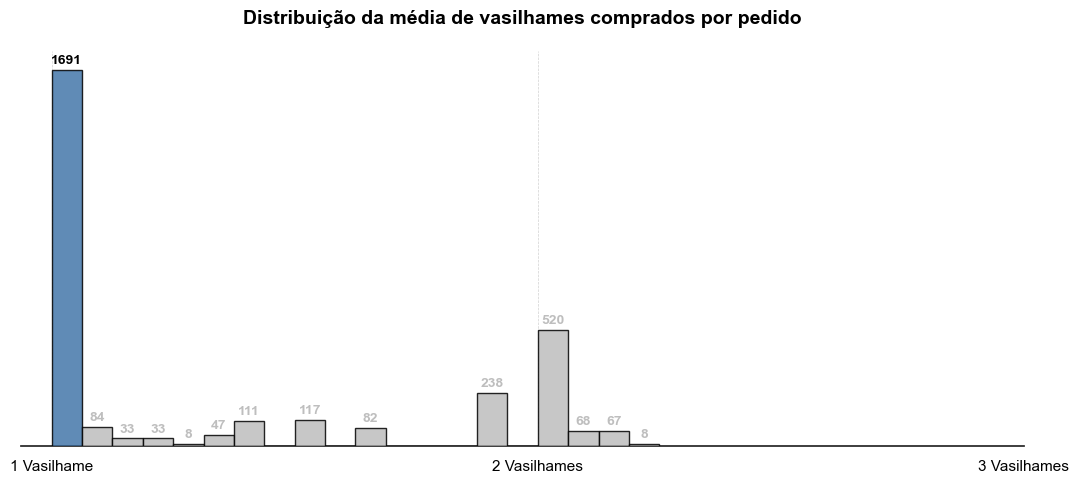

In [9]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(11, 5))

# Preparação dos dados: Filtra apenas os nulos, mantendo todos os volumes históricos
dados_media_aguas = df["cli_media_aguas_por_pedido"].dropna()

# Criação do histograma com bins (caixas de agrupamento)
contagens, limites_bins = np.histogram(dados_media_aguas, bins=20)

# Descobre qual bin (faixa) possui o maior número de registros para destacar
indice_maximo = contagens.argmax()

# Grades ao fundo
plt.grid(
    True,
    which="both",
    axis="both",
    color=PALETA["cinza"],
    linestyle="--",
    linewidth=0.5,
    alpha=0.7,
)

# Plotagem do Histograma utilizando patches para colorir as barras individualmente
n, bins, patches = plt.hist(
    dados_media_aguas,
    bins=limites_bins,
    color=PALETA["cinza"],
    edgecolor=PALETA["preto"],
    alpha=0.85,
    zorder=3,
)

# Aplica a cor azul especificamente na barra de maior frequência
patches[indice_maximo].set_facecolor(PALETA["azul"])

# Adiciona as numerações de forma customizada em cima de cada barra
for i in range(len(patches)):
    valor = int(contagens[i])
    if valor > 0:
        cor_texto = PALETA["preto"] if i == indice_maximo else PALETA["cinza"]

        # Encontra o centro da barra no eixo X para posicionar o texto
        centro_x = (limites_bins[i] + limites_bins[i+1]) / 2

        plt.annotate(
            f"{valor}",
            (centro_x, valor),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor_texto,
            zorder=4,
        )

# Remoção das bordas superior, direita e esquerda
sns.despine(top=True, right=True, left=True)

# Remove os números de escala do eixo vertical
plt.yticks([])

# Título
plt.title(
    "Distribuição da média de vasilhames comprados por pedido",
    fontsize=14,
    pad=20,
    fontweight="bold",
    color=PALETA["preto"],
)

# Cria marcações fixas e limpas do valor mínimo ao máximo de 1 em 1
min_x = int(np.floor(dados_media_aguas.min()))
max_x = int(np.ceil(dados_media_aguas.max()))
valores_ticks_x = list(range(min_x, max_x + 1))

# Aplica o texto de "Vasilhame" apenas nessas marcas principais e inteiras
legendas_ticks_x = [
    f"{x} Vasilhame" if x == 1 else f"{x} Vasilhames" for x in valores_ticks_x
]

# Define as posições limpas e as respectivas legendas no eixo X
plt.xticks(valores_ticks_x, legendas_ticks_x, color=PALETA["preto"], fontsize=11)

plt.tight_layout()
plt.show()

**Insights:** \
Ao análisar o gráfico revela uma base altamente polarizada entre dois perfis claros de consumo. O primeiro e maior grupo é composto por 1.691 clientes com média estrita de 1 vasilhame por pedido, refletindo um comportamento de reposição reativo de caráter residencial. Em contrapartida, observa-se um segundo núcleo focado em conveniência e estoque de segurança, liderado por 520 clientes com média de 2 vasilhames por pedido. Os registros intermediários demonstram flutuações sazonais pontuais, enquanto médias de consumo superiores a 2 unidades apresentam comportamento residual, delimitando o teto operacional dos pedidos padrões.

### D) Frequência histórica de compras:

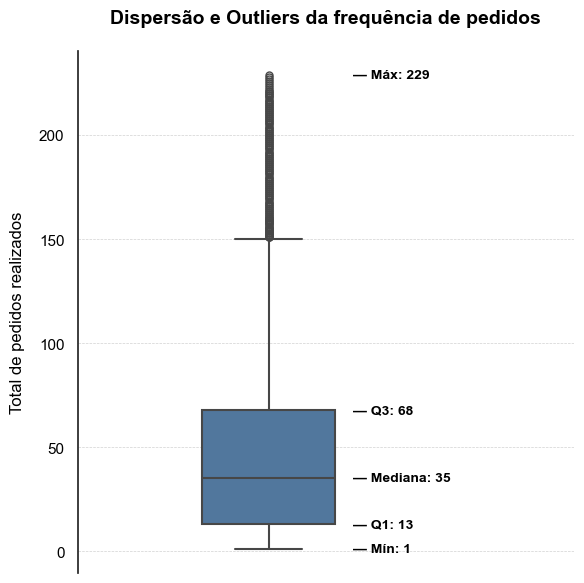

In [10]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(6, 6))

# Preparação dos dados: Filtra apenas os nulos
dados_frequencia_estatico = df["cli_frequencia_pedidos"].dropna()

# Cálculo dos 5 pontos estatísticos do Boxplot para as numerações
minimo = dados_frequencia_estatico.min()
q1 = dados_frequencia_estatico.quantile(0.25)
mediana = dados_frequencia_estatico.median()
q3 = dados_frequencia_estatico.quantile(0.75)
maximo = dados_frequencia_estatico.max()

# Grades ao fundo
plt.grid(True, which="both", axis="both", color=PALETA["cinza"], linestyle="--", linewidth=0.5, alpha=0.7)

# Plotagem do Boxplot vertical unificado
sns.boxplot(
    y=dados_frequencia_estatico,
    color=PALETA["azul"],
    linewidth=1.5,
    fliersize=5,
    width=0.35,
    zorder=3,
)

# Inserção das numerações de forma textual fora à direita do boxplot
pontos_estatisticos = [
    ("— Mín: " + str(int(minimo)), minimo),
    ("— Q1: " + str(int(q1)), q1),
    ("— Mediana: " + str(int(mediana)), mediana),
    ("— Q3: " + str(int(q3)), q3),
    ("— Máx: " + str(int(maximo)), maximo),
]

for texto, valor in pontos_estatisticos:
    plt.text(
        x=0.22,  # Deslocamento horizontal para a direita da caixa
        y=valor,  # Altura correspondente ao valor estatístico
        s=texto,  # Texto impresso
        ha="left",  # Alinhamento horizontal à esquerda para ler de forma natural
        va="center",  # Alinhamento vertical ao centro com a linha do boxplot
        fontsize=10,
        fontweight="bold",
        color=PALETA["preto"],
        zorder=4,
    )

# Controle das Bordas: Mantém explicitamente a linha da lateral esquerda
sns.despine(top=True, right=True, bottom=True, left=False)

# Remove marcações textuais do eixo X e expande ligeiramente o limite do eixo para o texto caber sem corte
plt.xticks([])
plt.xlabel("")
plt.xlim(-0.5, 0.8)

# Mantém as informações, legendas de escala e numerações ativas no eixo Y
plt.ylabel(
    "Total de pedidos realizados", fontsize=12, color=PALETA["preto"], labelpad=10
)
plt.yticks(color=PALETA["preto"], fontsize=11)

# Título
plt.title(
    "Dispersão e Outliers da frequência de pedidos",
    fontsize=14,
    pad=20,
    fontweight="bold",
    color=PALETA["preto"],
)

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico de distribuição revela que, embora a operação possua uma cauda longa de compradores históricos de altíssimo volume, o comportamento da base é majoritariamente concentrado em faixas de consumo iniciais e intermediárias. A mediana fixa-se em 35 pedidos acumulados por cliente, indicando que metade de toda a base ativa da plataforma já realizou até 35 compras ao longo do seu ciclo de vida. O corpo principal do negócio é delimitado pelo intervalo interquartílico, onde os clientes no primeiro quartil (Q1) registram a partir de 13 pedidos, e os clientes no terceiro quartil (Q3) alcançam até 68 pedidos acumulados. O limite superior padrão da distribuição estende-se de forma consistente até a marca de 150 entregas. Acima deste patamar, observa-se uma presença massiva e densa de outliers (pontos atípicos), que formam uma linha contínua vertical e culminam no limite máximo de 229 pedidos realizados por um único cliente. Esses pontos fora da curva não indicam erros de registro, mas sim a existência de uma persona real e valiosa de superconsumidores crônicos dentro do ecossistema.

**Recomendação de negócio (Framework estratégico):**
- **Régua de recompra para transição de faixa e ciclo de vida (LTV):**
    - **Hipótese:** Acredito que incentivar o cliente que está na faixa inicial a criar recorrência aumentará a previsibilidade do negócio, chancelando a estratégia de LTV proposta anteriormente, porque os dados do Boxplot provam que o grande desafio da plataforma é fazer o usuário cruzar a barreira do primeiro quartil (Q1: 13 pedidos) para amadurecer e avançar rumo à mediana de 35 pedidos acumulados.
    - **Ação:** Utilizar os limites matemáticos mapeados neste Boxplot para calibrar os gatilhos de recompra da ação anterior, disparando campanhas segmentadas com vantagens progressivas especificamente para a base que está na janela crítica entre 10 e 15 pedidos (pós-Q1), acelerando a transição desse cliente para as próximas faixas do ciclo de vida (marcos de 30 e 50 pedidos).
    - **Critério de sucesso:** Ao monitorar esse KPI saberei que funcionou quando o valor do primeiro quartil (Q1) subir de 13 para 20 pedidos acumulados e, consequentemente, o volume de clientes estagnados na base inferior do gráfico (abaixo de 35 pedidos) diminuir nos próximos ciclos.

## 3º - Fatores que influenciam a recompra
Objetivo: identificar quais características dos clientes e dos pedidos apresentam maior relação com o tempo até a próxima compra.

### A) Quantidade de águas entregues × Dias até a recompra:

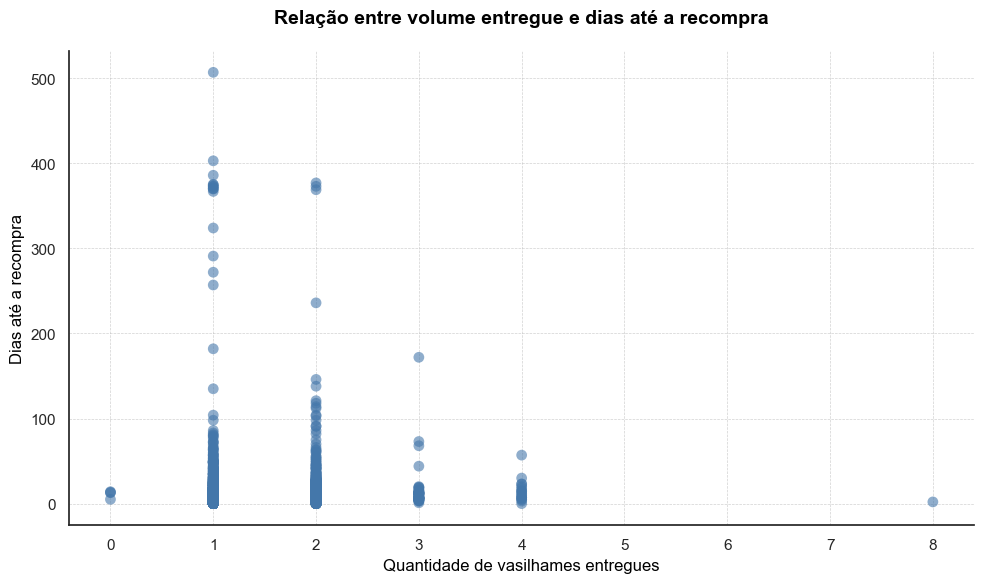

In [11]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Preparação dos dados: Filtra nulos das variáveis envolvidas
dados_scatter = df[
    ["qtd_aguas_entregues", "target_dias_ate_recompra"]
].dropna()

# Grades ao fundo
plt.grid(
    True,
    which="both",
    axis="both",
    color=PALETA["cinza"],
    linestyle="--",
    linewidth=0.5,
    alpha=0.7,
)

# Plotagem do Scatter Plot
# Todos os pontos ganham a cor azul da PALETA global
sns.scatterplot(
    data=dados_scatter,
    x="qtd_aguas_entregues",
    y="target_dias_ate_recompra",
    color=PALETA["azul"],
    alpha=0.6,  # Transparência para enxergar onde há sobreposição de pontos
    s=60,  # Tamanho dos pontos
    edgecolor="none",
    zorder=3,
)

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Legendas de texto (rótulos) dos eixos X e Y
plt.xlabel('Quantidade de vasilhames entregues', fontsize=12, color=PALETA["preto"])
plt.ylabel('Dias até a recompra', fontsize=12, color=PALETA["preto"])

# Título
plt.title(
    "Relação entre volume entregue e dias até a recompra",
    fontsize=14,
    pad=20,
    fontweight="bold",
    color=PALETA["preto"],
)

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico de dispersão revela um claro padrão de afunilamento do ciclo de recompra conforme o volume do pedido aumenta, validando que clientes de maior volumetria apresentam um comportamento de consumo crônico, previsível e altamente fiel. Nos pedidos de 1 e 2 vasilhames, observa-se uma dispersão vertical caótica e dispersa, que se estende até a faixa de 400 a 500 dias, sinalizando um público de conveniência residencial com baixa fidelidade de canal. Em contrapartida, à medida que o volume avança para 3, 4 e 8 unidades, ocorre um esmagamento drástico da variabilidade de tempo, com os limites de retorno fixando-se estritamente abaixo dos 100 dias. Esse comportamento atesta que compradores de grandes volumes possuem uma taxa de giro de estoque interna muito acelerada, o que os obriga a manter uma recompra constante e de curto prazo no deposito.

Este insight reafirma e justifica cientificamente a recomendação de Upsell (incentivar o cliente a comprar em pares ou lotes maiores) que foi proposto nas análises anteriores.

### B) Intervalo médio entre compras × Dias até a recompra:

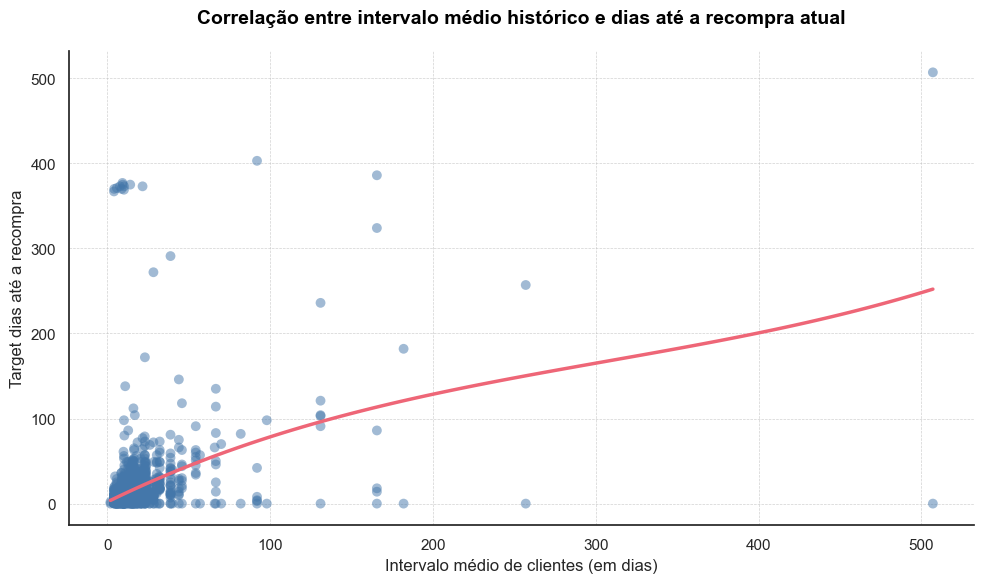

In [16]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Preparação dos dados: Filtra nulos das variáveis envolvidas
dados_tendencia = df[["cli_intervalo_medio", "target_dias_ate_recompra"]].dropna()

# Grades ao fundo
plt.grid(
    True,
    which="both",
    axis="both",
    color=PALETA["cinza"],
    linestyle="--",
    linewidth=0.5,
    alpha=0.7,
)

# Plotagem do Scatter Plot com linha de tendência
sns.regplot(
    data=dados_tendencia,
    x="cli_intervalo_medio",
    y="target_dias_ate_recompra",
    ci=None,  # Remove a faixa sombreada de intervalo de confiança para limpar o visual
    scatter_kws={
        "color": PALETA["azul"],
        "alpha": 0.5,
        "s": 50,
        "edgecolor": "none",
    },
    line_kws={"color": PALETA["vermelho"], "linewidth": 2.5},
    order=3,
)

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Legendas de texto (rótulos) dos eixos X e Y
plt.xlabel("Intervalo médio de clientes (em dias)")
plt.ylabel("Target dias até a recompra")

# Título
plt.title(
    "Correlação entre intervalo médio histórico e dias até a recompra atual",
    fontsize=14,
    pad=20,
    fontweight="bold",
    color=PALETA["preto"],
)

plt.tight_layout()
plt.show()

**Insights:** \
O gráfico revela uma correlação linear positiva entre o intervalo histórico e os dias até a recompra atual, provando que o comportamento passado do cliente é um preditor altamente confiável para o planejamento logístico. A forte densidade de pontos concentrada entre 0 e 50 dias em ambos os eixos confirma que a maior parte da base mantém um ritmo estável, fiel e previsível de consumo. Contudo, o modelo isola um sinal crítico de alerta de churn no quadrante superior esquerdo: clientes com histórico de recompra rápida (abaixo de 25 dias) romperam abruptamente o hábito e acumulam mais de um ano de inatividade. Essa quebra severa no ciclo de vida de clientes valiosos evidencia a necessidade urgente de implementar gatilhos automáticos de reativação assim que o cliente atrasar seu padrão usual de pedidos.

### C) Total de pedidos × Dias até a recompra:

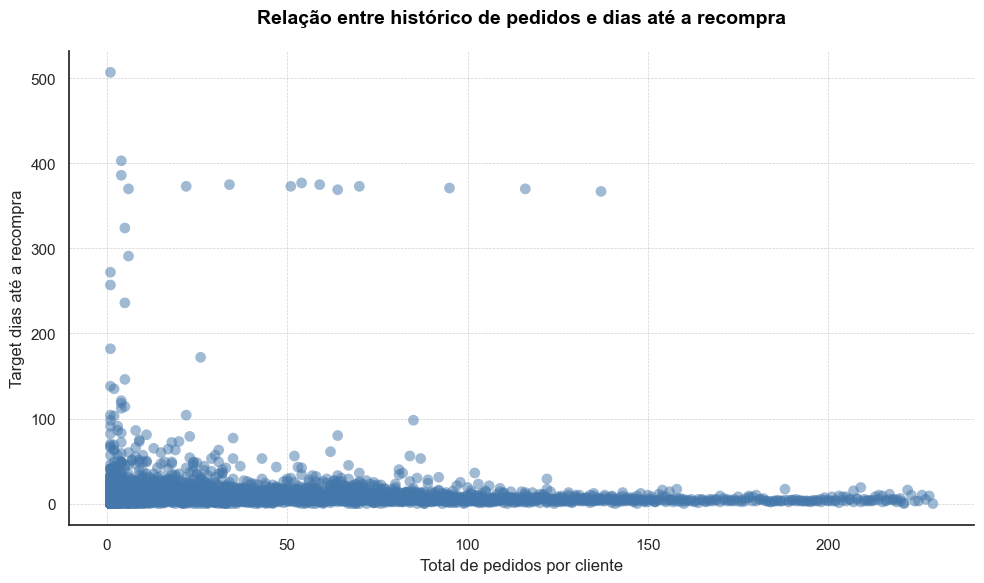

In [ ]:
# Configuração do estilo visual de fundo
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Preparação dos dados: Filtra nulos das variáveis envolvidas
dados_scatter_hist = df[["cli_total_pedidos", "target_dias_ate_recompra"]].dropna()

# Grades ao fundo
plt.grid(
    True,
    which="both",
    axis="both",
    color=PALETA["cinza"],
    linestyle="--",
    linewidth=0.5,
    alpha=0.7,
)

# Plotagem do Scatter Plot
# Todos os pontos ganham a cor azul da PALETA global 
sns.scatterplot(
    data=dados_scatter_hist,
    x="cli_total_pedidos",
    y="target_dias_ate_recompra",
    color=PALETA["azul"],
    alpha=0.5,  # Essencial para identificar onde há maior densidade de clientes acumulados
    s=60,       # Tamanho dos pontos
    edgecolor="none",
    zorder=3,
)

# Remoção das bordas superior e direita
sns.despine(top=True, right=True)

# Legendas de texto (rótulos) dos eixos X e Y
plt.xlabel("Total de pedidos por cliente")
plt.ylabel("Target dias até a recompra")

# Título
plt.title(
    "Relação entre histórico de pedidos e dias até a recompra",
    fontsize=14,
    pad=20,
    fontweight="bold",
    color=PALETA["preto"],
)

plt.tight_layout()
plt.show()

**Insight:** \
O gráfico revela que os clientes com maior volume de pedidos acumulados no histórico compram água com uma frequência muito mais alta e previsível, apresentando um tempo de retorno concentrado e próximo a zero. Nos estágios iniciais da jornada do cliente, na faixa de 0 a 25 pedidos totais, observa-se uma dispersão vertical caótica, com o tempo de recompra variando de 0 até mais de 500 dias, indicando hábitos altamente instáveis. Em contrapartida, conforme o cliente ganha tempo de casa e avança para além de 50 pedidos, ocorre um esmagamento total dessa variabilidade, com os pontos colando-se de forma rígida na base inferior. Essa compressão prova que clientes maduros desenvolvem uma dependência crônica de recompra de curtíssimo prazo. Contudo, o modelo isola um alerta crítico na faixa dos 370 dias de inatividade atingindo clientes consolidados com histórico de até 140 pedidos. Esse comportamento valida e chancela definitivamente a estratégia de relacionamento por ciclo de vida (safra/cohort) e as réguas de reativação contra o Churn propostas anteriormente, provando a necessidade de blindar o amadurecimento dos clientes.

### E) Média de águas por pedido × Dias até a recompra:

Variáveis:

- cli_media_aguas_por_pedido
- target_dias_ate_recompra

Ideias de gráficos:

Scatter Plot \
Boxplot

### F) Estação do ano × Dias até a recompra:

Variáveis:

- dt_estacao
- target_dias_ate_recompra

Ideias de gráfico:

Boxplot

## 4º - Correlação entre variáveis
Objetivo: validar estatisticamente as relações observadas durante a análise exploratória e identificar quais variáveis possuem maior potencial preditivo.

### A) Correlação entre as variáveis numéricas:

Gráfico:

Heatmap de correlação

## Conclusão